# Day 2

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras

## Fashion MNIST

train: 60,000
test : 10,000


,0,1,2,3,4,5,6,7,8,9
label,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot


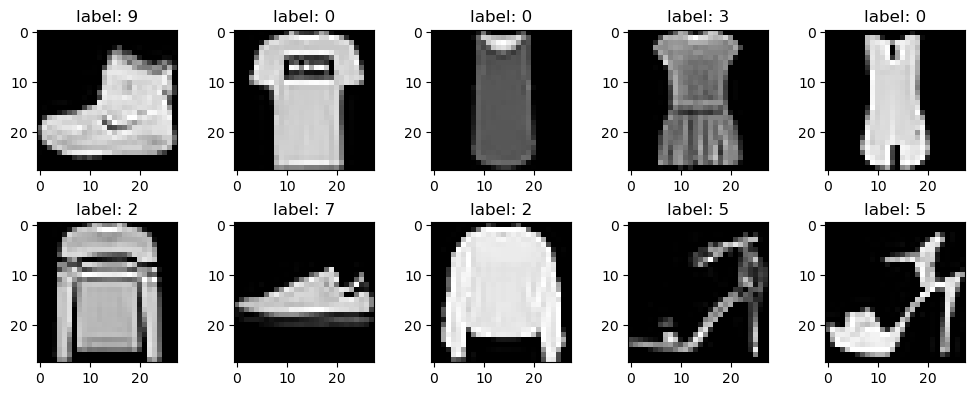

In [2]:
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms

전처리 = transforms.ToTensor()

fashion_mnist = {}
for split in ['train', 'test']:
    fashion_mnist[split] = FashionMNIST(
        root='data', train=(split=='train'), download=True, transform=전처리)
    print(f'{split:<5}: {len(fashion_mnist[split]):,}')

display(pd.DataFrame({'label': FashionMNIST.classes}).T)
plt.figure(figsize=(10, 4))
for i, (sample, label) in zip(range(10), fashion_mnist['train']):
    # print(type(sample), sample.shape, sample.dtype)
    sample = sample.squeeze() # (1, 28, 28) -> (28, 28)
    # print(type(sample), sample.shape, sample.dtype)
    # 이미지 시각화
    plt.subplot(2, 5, i + 1) # 2행 5열의 i+1번째 위치
    plt.imshow(sample, cmap='gray')
    plt.title(f'label: {label}')

plt.tight_layout()
plt.show()

In [7]:
sample, label = fashion_mnist['train'][0]
print(type(sample), sample.shape)
display(pd.DataFrame({'label': FashionMNIST.classes}).T)

<class 'torch.Tensor'> torch.Size([1, 28, 28])


,0,1,2,3,4,5,6,7,8,9
label,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

# 전처리: sklearn 모델에 입력할 수 있도록 데이터를 numpy 배열로 변환
X_train = fashion_mnist['train'].data.numpy()
X_train = X_train / 255.0 # 픽셀 값을 0과 1 사이로 정규화
# flatten
X_train = X_train.reshape(-1, 28*28) # (60000, 28, 28) -> (60000, 784)
print(X_train.shape, X_train.dtype, X_train.min(), X_train.max())
y_train = fashion_mnist['train'].targets.numpy()

model.fit(X_train, y_train)
scores = {'train': model.score(X_train, y_train)}
print(pd.Series(scores).round(4))

(60000, 784) float64 0.0 1.0
train    0.8806
dtype: float64


In [ ]:
from keras import layers

model = keras.Sequential()
model.add(keras.Input(shape=(1, 28, 28)))
# 벡터화
model.add(layers.Flatten())
# 은닉층 추가
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
# 출력층
model.add(layers.Dense(10, activation='softmax'))

model.summary()

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

# 모델 학습을 위한 배치 생성기
dataloaders = {}
for split in fashion_mnist.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train'))
    print(f'{split:<5}: {len(dataloaders[split]):,} batches')

history = model.fit(
    dataloaders['train'], epochs=10, 
    validation_data=dataloaders['test']
)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

train: 469 batches
test : 79 batches
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.7617 - loss: 0.6780 - val_accuracy: 0.8553 - val_loss: 0.4070
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8669 - loss: 0.3696 - val_accuracy: 0.8592 - val_loss: 0.3908
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8816 - loss: 0.3237 - val_accuracy: 0.8646 - val_loss: 0.3621
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8897 - loss: 0.2998 - val_accuracy: 0.8761 - val_loss: 0.3477
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8980 - loss: 0.2732 - val_accuracy: 0.8781 - val_loss: 0.3364
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9026 - loss: 0.2599 - val_accuracy: 0.8771 - val_loss: 0.3374
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9066 - loss: 0.2504 - val_accuracy: 0.8849 - val_loss: 0.3269
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step

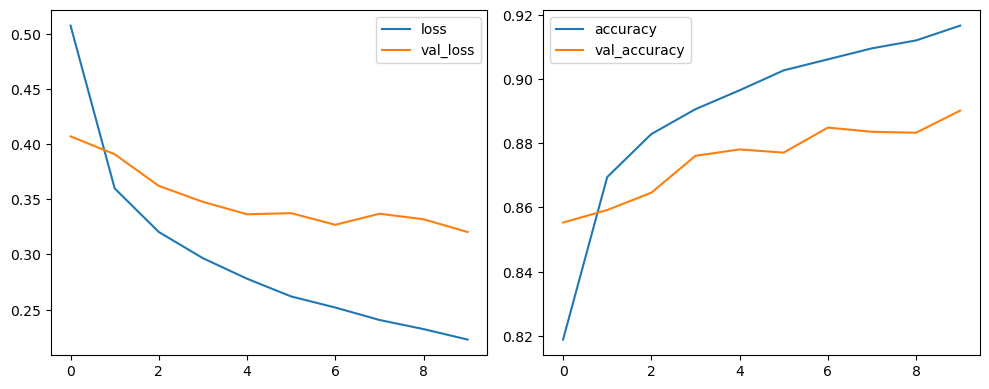

,accuracy,loss,val_accuracy,val_loss
0,0.82,0.51,0.86,0.41
1,0.87,0.36,0.86,0.39
2,0.88,0.32,0.86,0.36
3,0.89,0.30,0.88,0.35
4,0.90,0.28,0.88,0.34
5,0.90,0.26,0.88,0.34
6,0.91,0.25,0.88,0.33
7,0.91,0.24,0.88,0.34
8,0.91,0.23,0.88,0.33
9,0.92,0.22,0.89,0.32


In [50]:
results = pd.DataFrame(history.history)

plt.figure(figsize=(10, 4))
왼쪽 = plt.subplot(1, 2, 1) # 1행 2열의 1번째 위치
results.plot(y=['loss', 'val_loss'], ax=왼쪽)
오른쪽 = plt.subplot(1, 2, 2) # 1행 2열의 2번째 위치
results.plot(y=['accuracy', 'val_accuracy'], ax=오른쪽)
plt.tight_layout()
plt.show()

display(results.round(2))

In [51]:
test_results = model.evaluate(dataloaders['test'], return_dict=True)
print(pd.Series(test_results).round(4))

 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8750 - loss: 0.3652

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8894 - loss: 0.3240
accuracy    0.8902
loss        0.3203
dtype: float64


In [24]:
X_train, y_train = next(iter(dataloaders['train']))
print(f'입력 데이터: {X_train.device}')
# Keras 모델은 자동으로 GPU를 탐지하고, 활용
outputs = model(X_train)
print(f'출력 데이터: {outputs.device}') # cuda

입력 데이터: cpu
출력 데이터: cuda:0


## GPU 가속

In [ ]:
x = torch.linspace(0, 1, 5)
print(x.device, x)
assert torch.all(x - x == 0)

x2 = x.to('cuda')
print(x2.device, x2)
assert torch.all(x2 - x2 == 0)

try:
    assert torch.all(x - x2 == 0)
except Exception as e:
    print(e)

cpu tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
cuda:0 tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000], device='cuda:0')
Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!


In [46]:
all_inputs = []; all_outputs = []; all_labels = []
for X_batch, y_batch in dataloaders['train']:
    outputs = model.predict(X_batch, verbose=0)
    all_inputs.append(X_batch.numpy())
    all_outputs.append(outputs)
    all_labels.append(y_batch.numpy())

all_inputs = np.concatenate(all_inputs, axis=0)
all_outputs = np.concatenate(all_outputs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

예측 = np.argmax(all_outputs, axis=1)
채점 = 예측 == all_labels
print(f'{채점.sum()}/{len(채점)} = {채점.mean():.2%}')

55193/60000 = 91.99%


,0,1,2,3,4,5,6,7,8,9
label,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot


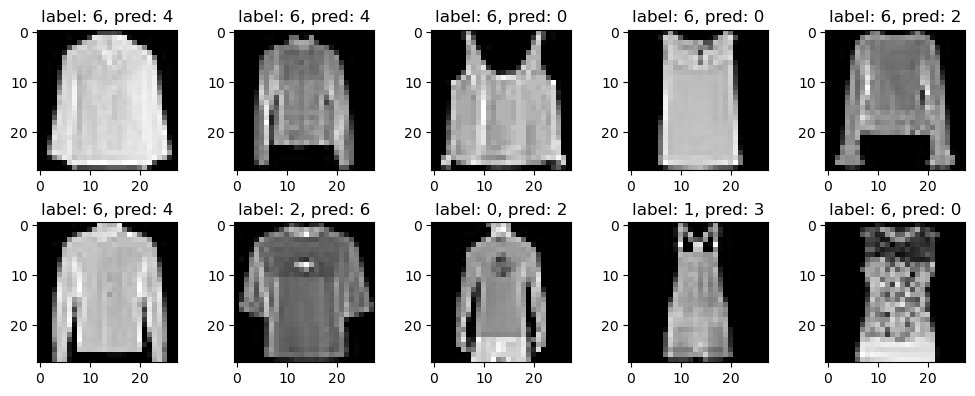

In [48]:
display(pd.DataFrame({'label': FashionMNIST.classes}).T)
오답필터 = np.logical_not(채점)
plt.figure(figsize=(10, 4))
for i, xi, yi, pi in zip(range(10), all_inputs[오답필터], all_labels[오답필터], 예측[오답필터]):
    plt.subplot(2, 5, i + 1) # 2행 5열의 i+1번째 위치
    plt.imshow(xi.squeeze(), cmap='gray')
    plt.title(f'label: {yi}, pred: {pi}')

plt.tight_layout()
plt.show()

## 합성곱 신경망

Convolutional Neural Network, ConvNet

In [60]:
import keras
from keras import layers

# 계산그래프 초기화
# 이전 모델의 계산그래프가 남아있을 수 있으므로 초기화
keras.backend.clear_session()

model = keras.Sequential()
model.add(keras.Input(shape=(1, 28, 28))) # channels first 형식: (채널, 높이, 너비)
# 은닉층
for units in [32, 64]:
    model.add(layers.Conv2D(units, kernel_size=3, activation='relu', data_format='channels_first'))
    model.add(layers.MaxPooling2D(pool_size=2, data_format='channels_first'))
# 출력층
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))
model.summary()

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

# 모델 학습을 위한 배치 생성기
dataloaders = {}
for split in fashion_mnist.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train'))
    print(f'{split:<5}: {len(dataloaders[split]):,} batches')

history = model.fit(
    dataloaders['train'], epochs=10, 
    validation_data=dataloaders['test']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 26, 26)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 13, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 11, 11)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 5, 5)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

train: 469 batches
test : 79 batches
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.6988 - loss: 0.8647 - val_accuracy: 0.8450 - val_loss: 0.4346
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8550 - loss: 0.4061 - val_accuracy: 0.8602 - val_loss: 0.3946
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8759 - loss: 0.3434 - val_accuracy: 0.8804 - val_loss: 0.3421
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8823 - loss: 0.3300 - val_accuracy: 0.8812 - val_loss: 0.3299
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8946 - loss: 0.2986 - val_accuracy: 0.8847 - val_loss: 0.3272
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8982 - loss: 0.2826 - val_accuracy: 0.8869 - val_loss: 0.3112
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9025 - loss: 0.2700 - val_accuracy: 0.8906 - val_loss: 0.3066
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step

## 댕냥이 데이터

In [5]:
from pathlib import Path

폴더 = Path('data/cats_dogs_small')
assert 폴더.is_dir(), f'{폴더} 폴더가 없습니다.'

# 하위 폴더 확인
for 하위폴더 in 폴더.iterdir():
    print(하위폴더)

# 파일 획득
files = {}
for split in ['train', 'validation', 'test']:
    files[split] = list((폴더 / split).glob('**/*.jpg'))
    print(f'{split:<10}: {len(files[split]):,} files')

data/cats_dogs_small/test
data/cats_dogs_small/train
data/cats_dogs_small/validation
train     : 2,000 files
validation: 1,000 files
test      : 2,000 files


data/cats_dogs_small/train/cat/cat.0.jpg
cat.0.jpg
cat.0
<class 'PIL.JpegImagePlugin.JpegImageFile'> (500, 374) RGB


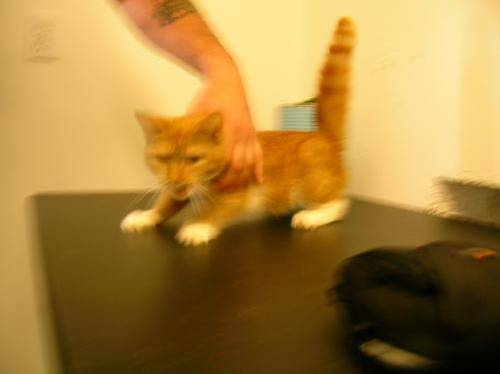

In [ ]:
# PIL: Python Imaging Library
import PIL.Image as Image

sample = files['train'][0]
print(sample)
print(sample.name)
print(sample.stem)
# PIL 라이브러리를 사용하여 이미지 열기
with Image.open(sample) as img:
    print(type(img), img.size, img.mode)
    # with 블럭 외부에서 img 객체는 자동으로 닫히므로, 복사본을 만들어서 사용
    sample = img.copy()
    
display(sample)

In [20]:
import PIL.Image as Image

class CatDogDataset:
    def __init__(self, 폴더, transform=None):
        self.폴더 = Path(폴더)
        self.파일들 = list(self.폴더.glob('**/*.jpg'))
        self.labels = {'cat': 0, 'dog': 1}
        self.transform = transform
    
    def __len__(self):
        return len(self.파일들)
    
    def __getitem__(self, 색인):
        파일 = self.파일들[색인]
        target = self.labels['cat' if 'cat' in 파일.stem else 'dog']
        with Image.open(파일) as img:
            sample = img.copy()
        if self.transform:
            sample = self.transform(sample)
        return sample, target

test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
<class 'torch.Tensor'>
label: dog


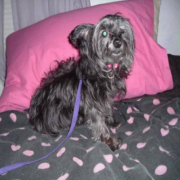

In [30]:
import torchvision.transforms as transforms

%run catdog.py

전처리 = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.ToTensor()
])

datasets = {}
for 하위폴더 in 폴더.iterdir():
    split = 하위폴더.name
    datasets[split] = CatDogDataset(하위폴더, transform=전처리)
    print(f'{split:<10}: {len(datasets[split]):,} samples')

sample, label = datasets['train'][1000]
print(type(sample))
print(f"label: {'cat' if label == 0 else 'dog'}")
try:
    sample - sample
except Exception as e:
    # 이미지 객체는 연산 불가
    print(e)

display(transforms.ToPILImage()(sample))

In [31]:
import torch

dataloaders = {}
for split in datasets.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        datasets[split], batch_size=32, shuffle=(split=='train'))
    print(f'{split:<10}: {len(dataloaders[split]):,} batches')

for X_batch, y_batch in dataloaders['train']:
    print(X_batch.shape, y_batch.shape)
    break

test      : 63 batches
train     : 63 batches
validation: 32 batches
torch.Size([32, 3, 180, 180]) torch.Size([32])


## 댕냥이 모델

In [ ]:
from keras import layers

keras.backend.clear_session()
# keras.backend.set_image_data_format('channels_last')

model = keras.Sequential()
model.add(keras.Input(shape=(3, 180, 180))) # channels first 형식
# (C, H, W) -> (H, W, C)로 변환하는 레이어
model.add(layers.Permute((2, 3, 1))) # (B, C, H, W) -> (B, H, W, C)
# 은닉층
for units in [32, 64, 128, 256]:
    model.add(layers.Conv2D(
        units, kernel_size=3, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=2))

model.add(layers.Conv2D(256, kernel_size=3, activation='relu'))
# 출력층
model.add(layers.Flatten())
model.add(layers.Dense(1, activation='sigmoid')) # 이진 분류 출력

model.summary()

model.compile(
    # 이진 분류 문제이므로, BinaryCrossentropy 손실 함수를 사용
    loss=keras.losses.BinaryCrossentropy(),
    # 학습률 튜닝을 줄이기 위해 자동 학습률 조정 가능한 RMSprop 사용
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)

%run catdog.py
history = model.fit(
    dataloaders['train'],
    validation_data=dataloaders['validation'],
    epochs=30,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'catdog.keras', save_best_only=True, monitor='val_loss'),
        # # 조기 종료
        # keras.callbacks.EarlyStopping(
        #     monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute (Permute)               │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
test      : 63 batches
train     : 63 batches
validation: 32 batches
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.4902 - loss: 0.7131 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.5272 - loss: 0.6957 - val_accuracy: 0.5760 - val_loss: 0.6851
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5593 - loss: 0.6862 - val_accuracy: 0.6000 - val_loss: 0.6710
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5919 - loss: 0.6696 - val_accuracy: 0.6250 - val_loss: 0.6460
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.6318 - loss: 0.6434 - val_accuracy: 0.6170 - val_loss: 0.6589
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6817 - loss: 0.6103 - val_accuracy: 0.7040 - val_loss: 0.5855
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6879 - loss: 0.5728 - val_

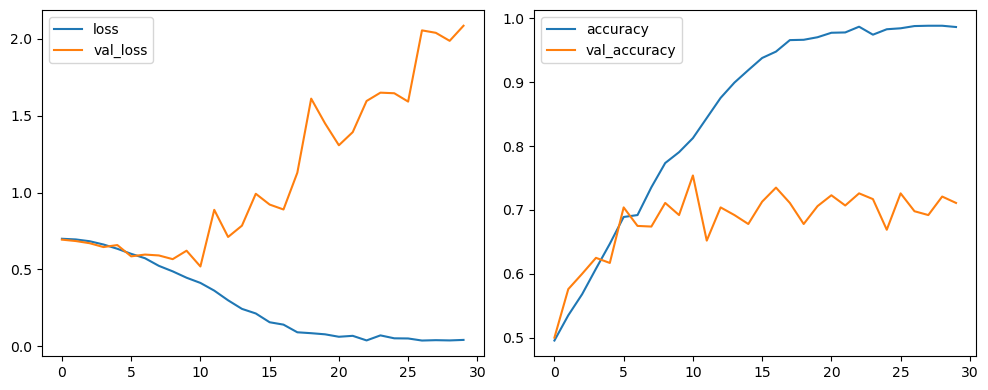

,accuracy,loss,val_accuracy,val_loss
0,0.50,0.70,0.50,0.69
1,0.54,0.70,0.58,0.69
2,0.57,0.68,0.60,0.67
3,0.61,0.66,0.62,0.65
4,0.65,0.63,0.62,0.66
5,0.69,0.60,0.70,0.59
6,0.69,0.57,0.68,0.60
7,0.74,0.52,0.67,0.59
8,0.77,0.49,0.71,0.57
9,0.79,0.45,0.69,0.62


In [60]:
train_results = pd.DataFrame(history.history)
plt.figure(figsize=(10, 4))
왼쪽 = plt.subplot(1, 2, 1) # 1행 2열의 1번째 위치
train_results.plot(y=['loss', 'val_loss'], ax=왼쪽)
오른쪽 = plt.subplot(1, 2, 2) # 1행 2열의 2번째 위치
train_results.plot(y=['accuracy', 'val_accuracy'], ax=오른쪽)
plt.tight_layout()
plt.show()

train_results.round(2)

In [61]:
# best 모델 로드
model = keras.models.load_model('catdog.keras')
test_results = model.evaluate(dataloaders['test'], return_dict=True)
print(pd.Series(test_results).round(4))

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7510 - loss: 0.5464
accuracy    0.7415
loss        0.5647
dtype: float64


## 데이터 증식

In [67]:
# %load catdog.py
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL.Image as Image
import torch

class CatDogDataset:
    def __init__(self, 폴더, transform=None):
        self.폴더 = Path(폴더)
        self.파일들 = list(self.폴더.glob('**/*.jpg'))
        self.labels = {'cat': 0, 'dog': 1}
        self.transform = transform
    
    def __len__(self):
        return len(self.파일들)
    
    def __getitem__(self, 색인):
        파일 = self.파일들[색인]
        target = self.labels['cat' if 'cat' in 파일.stem else 'dog']
        with Image.open(파일) as img:
            sample = img.copy()
        if self.transform:
            sample = self.transform(sample)
        return sample, target
    

def get_dataloaders(datasets, **설정):
    print('# 데이터로더')
    dataloaders = {}
    for split in datasets.keys():
        dataloaders[split] = torch.utils.data.DataLoader(
            datasets[split], shuffle=(split=='train'),
            **설정
        )
        print(f'{split:<10}: {len(dataloaders[split]):,} batches')
    return dataloaders

def get_train_results(history):
    train_results = pd.DataFrame(history.history)
    plt.figure(figsize=(10, 4))
    왼쪽 = plt.subplot(1, 2, 1) # 1행 2열의 1번째 위치
    train_results.plot(y=['loss', 'val_loss'], ax=왼쪽)
    오른쪽 = plt.subplot(1, 2, 2) # 1행 2열의 2번째 위치
    train_results.plot(y=['accuracy', 'val_accuracy'], ax=오른쪽)
    plt.tight_layout()
    plt.show()
    return train_results


In [71]:
# 검증/시험 데이터는 원래 전처리
전처리 = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.ToTensor()
])
# 훈련 데이터에만 적용
훈련전처리 = transforms.Compose([
    transforms.RandomHorizontalFlip(), # 좌우 반전
    transforms.RandomRotation(20), # 20도 범위 내에서 랜덤 회전
    transforms.RandomResizedCrop((180, 180), scale=(0.8, 1.0)), # 랜덤 크롭 및 리사이즈
    transforms.ToTensor()
])

for split in ['train', 'validation', 'test']:
    datasets[split] = CatDogDataset(
        폴더 / split, transform=훈련전처리 if split == 'train' else 전처리)

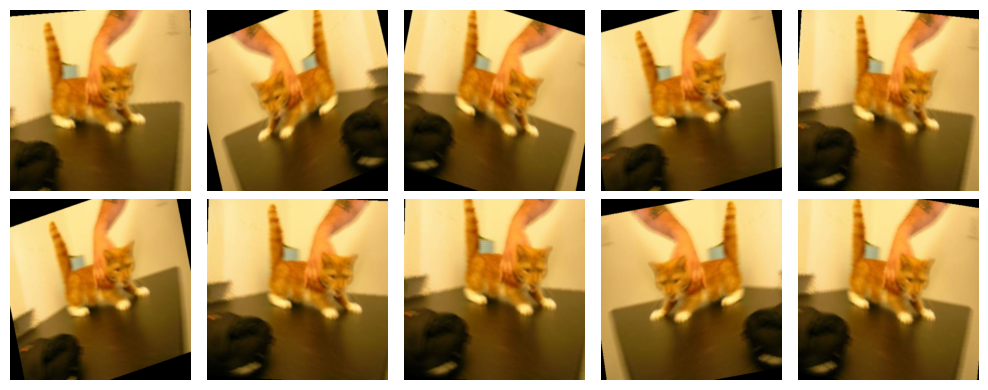

In [91]:
plt.figure(figsize=(10, 4))
for i in range(10):
    sample, label = datasets['train'][0]
    plt.subplot(2, 5, i + 1) # 2행 5열의 i+1번째 위치
    plt.imshow(sample.permute(1, 2, 0)) # (C, H, W) -> (H, W, C)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [94]:
from keras import layers

keras.backend.clear_session()
# keras.backend.set_image_data_format('channels_last')

model = keras.Sequential()
model.add(keras.Input(shape=(3, 180, 180))) # channels first 형식
# (C, H, W) -> (H, W, C)로 변환하는 레이어
model.add(layers.Permute((2, 3, 1))) # (B, C, H, W) -> (B, H, W, C)
# 은닉층
for units in [32, 64, 128, 256]:
    model.add(layers.Conv2D(
        units, kernel_size=3, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=2))

model.add(layers.Conv2D(256, kernel_size=3, activation='relu'))
# 출력층
model.add(layers.Flatten())
model.add(layers.Dense(1, activation='sigmoid')) # 이진 분류 출력

model.summary()

model.compile(
    # 이진 분류 문제이므로, BinaryCrossentropy 손실 함수를 사용
    loss=keras.losses.BinaryCrossentropy(),
    # 학습률 튜닝을 줄이기 위해 자동 학습률 조정 가능한 RMSprop 사용
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)

%run catdog.py
dataloaders = get_dataloaders(
    datasets, batch_size=32, num_workers=8)

history = model.fit(
    dataloaders['train'],
    validation_data=dataloaders['validation'],
    epochs=100,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'catdog.keras', save_best_only=True, monitor='val_loss'),
    ]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute (Permute)               │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

# 데이터로더
test      : 63 batches
train     : 63 batches
validation: 32 batches
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.5129 - loss: 0.7166 - val_accuracy: 0.5160 - val_loss: 0.6914
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.5308 - loss: 0.6926 - val_accuracy: 0.5010 - val_loss: 0.7495
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.5309 - loss: 0.6977 - val_accuracy: 0.5000 - val_loss: 1.7330
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.5768 - loss: 0.7503 - val_accuracy: 0.6090 - val_loss: 0.6599
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.6445 - loss: 0.6533 - val_accuracy: 0.6330 - val_loss: 0.6348
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.6435 - loss: 0.6324 - val_accuracy: 0.6620 - val_loss: 0.6341
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.6398 - loss: 0.6375 - val_accuracy: 0.6650 - val_loss: 0.6151
Epoch 8/100
63/63 ━━━━━━━━━

In [ ]:
model = keras.models.load_model('catdog.keras')
test_results = model.evaluate(dataloaders['test'], return_dict=True)
test_results = pd.Series(test_results).round(4)

train_results = get_train_results(history)